# Formativa 2 - Modelamiento Predictivo

## Framingham Heart Study

**Integrantes:**

- Francisco Santelices
- Renato Villazon
- Fabian Castillo

---

### Objetivo

Desarrollar un modelo de regresión logística para predecir el riesgo de enfermedad coronaria a diez años (TenYearCHD), integrando los principales resultados obtenidos durante la Sumativa 1 y la Sumativa 2.

En esta actividad se realizará:

- Preparación de los datos para modelamiento.
- Selección justificada de variables predictoras.
- Ajuste de un modelo de regresión logística.
- Evaluación del desempeño predictivo mediante métricas de clasificación.
- Diagnóstico de multicolinealidad.
- Reflexión final sobre el proceso de modelamiento.

In [1]:
import numpy as np

np.random.seed(42)

In [2]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")

In [3]:
BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebook":
    BASE_DIR = BASE_DIR.parent

CSV_FILE = BASE_DIR / "data" / "framingham.csv"

df = pd.read_csv(CSV_FILE)

print(df.shape)
df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 1. Preparación de datos para el modelamiento

Antes de construir el modelo predictivo se preparó el conjunto de datos considerando los principales hallazgos obtenidos durante las evaluaciones anteriores.

En la **Sumativa 1** se identificaron las variables con mayor relación con el riesgo cardiovascular mediante estadística descriptiva, análisis de correlación y pruebas de hipótesis.

Posteriormente, en la **Sumativa 2**, dichas conclusiones fueron validadas utilizando técnicas de remuestreo Bootstrap, simulaciones Monte Carlo, análisis de robustez y evaluación del impacto del proceso de limpieza de datos.

A partir de estos resultados se construirá un modelo de regresión logística utilizando únicamente variables que demostraron estabilidad estadística y relevancia clínica.

In [4]:
print("Dimensiones del dataset:", df.shape)

display(df.head())

Dimensiones del dataset: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 1.3 Limpieza de datos

Se aplicó la misma estrategia utilizada durante la Sumativa 1.

Los registros con valores faltantes fueron eliminados mediante **Listwise Deletion**, obteniéndose un conjunto final de observaciones completas.

En la Sumativa 2 se verificó que este procedimiento no modificó significativamente las características generales de la muestra, por lo que se mantuvo para el desarrollo del modelo predictivo.

In [5]:
print("Registros originales :", len(df))

df = df.dropna()

print("Registros utilizados :", len(df))

Registros originales : 4240
Registros utilizados : 3658


In [6]:
df["pulsePressure"] = df["sysBP"] - df["diaBP"]

df[["sysBP","diaBP","pulsePressure"]].head()

,sysBP,diaBP,pulsePressure
0,106.0,70.0,36.0
1,121.0,81.0,40.0
2,127.5,80.0,47.5
3,150.0,95.0,55.0
4,130.0,84.0,46.0


## 1.4 Ingeniería de variables

Durante la Sumativa 2 se observó una alta correlación entre la presión arterial sistólica y diastólica, lo que podría generar problemas de multicolinealidad en el modelo de regresión logística.

Para reducir este efecto se incorporó la variable **Presión de Pulso (Pulse Pressure)**, definida como la diferencia entre la presión sistólica y diastólica.

Esta variable representa un indicador clínico ampliamente utilizado para evaluar la rigidez arterial y permite resumir parte de la información contenida en ambas mediciones.

# 2. Selección de variables predictoras

La selección de variables se realizó considerando los resultados obtenidos en la Sumativa 1 y la Sumativa 2.

Se priorizaron variables que mostraron estabilidad estadística, relevancia clínica y baja redundancia entre predictores. Además, se incorporó la variable `pulsePressure` para reemplazar el uso conjunto de `sysBP` y `diaBP`, reduciendo posibles problemas de colinealidad.

Variables seleccionadas:

- `age`: edad del paciente.
- `totChol`: colesterol total.
- `BMI`: índice de masa corporal.
- `glucose`: nivel de glucosa.
- `pulsePressure`: presión de pulso.

In [7]:
features = [
    "age",
    "totChol",
    "BMI",
    "glucose",
    "pulsePressure"
]

target = "TenYearCHD"

X = df[features]
y = df[target]

print("Variables predictoras:")
print(features)

print("\nVariable objetivo:")
print(target)

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variables predictoras:
['age', 'totChol', 'BMI', 'glucose', 'pulsePressure']

Variable objetivo:
TenYearCHD

Dimensiones de X: (3658, 5)
Dimensiones de y: (3658,)


In [8]:
y.value_counts(normalize=True).mul(100).round(2)

TenYearCHD
0    84.77
1    15.23
Name: proportion, dtype: float64

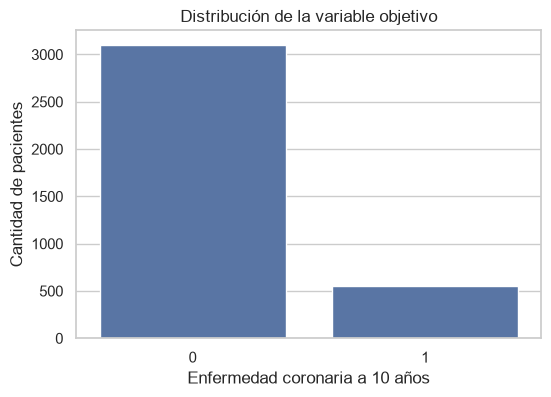

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="TenYearCHD"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Enfermedad coronaria a 10 años")
plt.ylabel("Cantidad de pacientes")

plt.show()

La variable objetivo presenta desbalance de clases, ya que la mayoría de los pacientes no desarrolló enfermedad coronaria a diez años. Este aspecto debe considerarse al interpretar métricas como accuracy, por lo que también se evaluarán precision, recall, F1-score y AUC.

## 2.2 División del conjunto de datos

Para evaluar la capacidad predictiva del modelo se dividió el conjunto de datos en dos subconjuntos:

- **70%** para entrenamiento.
- **30%** para prueba.

Se utilizó un muestreo estratificado sobre la variable objetivo (`TenYearCHD`) con el fin de conservar la proporción de pacientes con y sin enfermedad coronaria en ambos conjuntos.

Esta estrategia permite entrenar el modelo sobre una muestra representativa y evaluar posteriormente su desempeño utilizando datos que no fueron empleados durante el ajuste del modelo.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Conjunto de entrenamiento")
print(X_train.shape)

print()

print("Conjunto de prueba")
print(X_test.shape)

Conjunto de entrenamiento
(2560, 5)

Conjunto de prueba
(1098, 5)


## 2.3 Escalamiento de variables

Las variables predictoras presentan diferentes unidades de medida (años, mg/dL, kg/m², mmHg), por lo que se aplicó una estandarización mediante `StandardScaler`.

Este procedimiento transforma las variables para que tengan media cero y desviación estándar uno, facilitando la convergencia del algoritmo y permitiendo comparar la magnitud de los coeficientes estimados por la regresión logística.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Entrenamiento:", X_train_scaled.shape)
print("Prueba:", X_test_scaled.shape)

Entrenamiento: (2560, 5)
Prueba: (1098, 5)


# 3. Modelo de Regresión Logística

Se ajustó un modelo de regresión logística para estimar la probabilidad de desarrollar enfermedad coronaria a diez años (`TenYearCHD`) utilizando las variables seleccionadas.

La regresión logística es un modelo ampliamente utilizado para problemas de clasificación binaria, ya que permite estimar probabilidades y analizar el efecto individual de cada variable predictora sobre el riesgo del evento de interés.

In [12]:
modelo = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [13]:
coeficientes = pd.DataFrame({

    "Variable": features,

    "Coeficiente": modelo.coef_[0]

})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    key=abs,
    ascending=False
)

coeficientes

,Variable,Coeficiente
0,age,0.468666
4,pulsePressure,0.293678
3,glucose,0.152485
1,totChol,0.110345
2,BMI,0.102355


### Interpretación

Los coeficientes estimados por la regresión logística representan la contribución relativa de cada variable predictora sobre la probabilidad de desarrollar enfermedad coronaria a diez años.

La **edad** presentó el mayor coeficiente positivo, indicando que el incremento de la edad se asocia con un mayor riesgo de enfermedad coronaria, resultado consistente con los análisis realizados en las evaluaciones anteriores.

La **presión de pulso** fue la segunda variable con mayor influencia, validando la decisión metodológica de utilizar esta variable derivada en lugar de incorporar simultáneamente la presión sistólica y diastólica, reduciendo así problemas de multicolinealidad.

La **glucosa**, el **colesterol total** y el **IMC** también mostraron coeficientes positivos, sugiriendo que mayores valores en estas variables incrementan la probabilidad estimada de presentar enfermedad coronaria.

En conjunto, los coeficientes obtenidos son coherentes con la evidencia clínica y con los resultados estadísticos obtenidos durante las Sumativas 1 y 2.

# 4. Diagnóstico de multicolinealidad

Antes de evaluar el desempeño del modelo, se verificó la existencia de multicolinealidad entre las variables predictoras mediante el **Factor de Inflación de la Varianza (Variance Inflation Factor, VIF)**.

El VIF cuantifica cuánto aumenta la varianza estimada de un coeficiente debido a la correlación con otras variables independientes. En términos generales:

- VIF < 5: multicolinealidad baja.
- VIF entre 5 y 10: multicolinealidad moderada.
- VIF > 10: multicolinealidad alta.

Este análisis permite confirmar que las variables seleccionadas pueden incorporarse simultáneamente en el modelo sin afectar significativamente la estabilidad de las estimaciones.

In [14]:
X_vif = pd.DataFrame(
    X_train_scaled,
    columns=features
)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

vif.round(2)

,Variable,VIF
0,age,1.26
4,pulsePressure,1.24
1,totChol,1.09
2,BMI,1.05
3,glucose,1.02


### Interpretación

El análisis mediante el Factor de Inflación de la Varianza (VIF) mostró valores comprendidos entre **1,02 y 1,26**, muy por debajo de los umbrales comúnmente utilizados para identificar problemas de multicolinealidad.

Estos resultados indican que las variables predictoras seleccionadas presentan un bajo grado de dependencia lineal entre sí, permitiendo estimar de forma estable los coeficientes del modelo de regresión logística.

Además, el bajo VIF obtenido para la variable **pulsePressure** confirma que la estrategia adoptada durante la Sumativa 2 para reemplazar el uso simultáneo de la presión sistólica y diastólica fue adecuada, reduciendo exitosamente la colinealidad observada en los análisis exploratorios previos.

En consecuencia, las variables seleccionadas constituyen un conjunto apropiado para el ajuste del modelo predictivo.

# 5. Evaluación del modelo

Una vez ajustado el modelo de regresión logística, se evaluó su capacidad predictiva utilizando el conjunto de prueba.

Para ello se calcularon las predicciones del modelo y posteriormente se analizaron distintas métricas de clasificación, permitiendo evaluar tanto la capacidad de identificar correctamente los casos positivos como el desempeño general del clasificador.

In [15]:
y_pred = modelo.predict(X_test_scaled)

y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

print("Primeras predicciones:")

predicciones = pd.DataFrame({

    "Valor real": y_test.values,

    "Predicción": y_pred,

    "Probabilidad CHD": np.round(y_prob, 3)

})

predicciones.head(10)

Primeras predicciones:


,Valor real,Predicción,Probabilidad CHD
0,0,0,0.110
1,0,0,0.175
2,0,0,0.083
3,0,0,0.109
4,0,0,0.076
5,1,0,0.333
6,1,0,0.071
7,0,0,0.087
8,1,0,0.150
9,0,0,0.045


## 5.1 Matriz de confusión

La matriz de confusión resume el número de clasificaciones correctas e incorrectas realizadas por el modelo sobre el conjunto de prueba.

Esta herramienta permite identificar la cantidad de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos, proporcionando una visión detallada del comportamiento del clasificador.

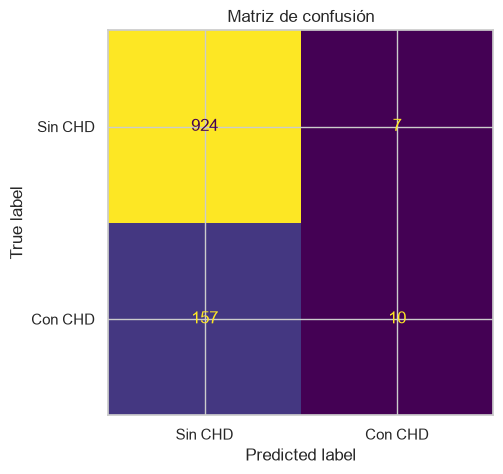

[[924   7]
 [157  10]]


In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Sin CHD",
        "Con CHD"
    ]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Matriz de confusión")

plt.show()

print(cm)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

metricas = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]

})

metricas.round(4)

,Métrica,Valor
0,Accuracy,0.8506
1,Precision,0.5882
2,Recall,0.0599
3,F1-score,0.1087


In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       931
           1       0.59      0.06      0.11       167

    accuracy                           0.85      1098
   macro avg       0.72      0.53      0.51      1098
weighted avg       0.81      0.85      0.80      1098



### Interpretación

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los pacientes que no desarrollan enfermedad coronaria, obteniendo un **Accuracy de 85,06%**.

Sin embargo, este resultado debe interpretarse con cautela debido al desbalance existente en la variable objetivo. Aunque el modelo presenta una **Precision de 58,82%**, el **Recall alcanza solo un 5,99%**, lo que indica una baja capacidad para identificar correctamente a los pacientes que sí desarrollarán enfermedad coronaria.

En consecuencia, el elevado Accuracy está influenciado por la alta proporción de pacientes sin enfermedad en la muestra, mientras que el modelo presenta dificultades para detectar los casos positivos.

Estos resultados evidencian que el modelo constituye un punto de partida adecuado, pero requiere mejoras adicionales para incrementar su capacidad predictiva sobre la clase minoritaria.

## 5.2 Curva ROC y Área Bajo la Curva (AUC)

La curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad discriminante del modelo para distinguir entre pacientes que desarrollarán y no desarrollarán enfermedad coronaria.

A diferencia del Accuracy, esta métrica considera el comportamiento del modelo para distintos umbrales de decisión, siendo especialmente útil cuando existe desbalance entre las clases.

El Área Bajo la Curva (AUC) resume esta capacidad discriminante mediante un único indicador, donde valores cercanos a 1 representan un excelente desempeño y valores próximos a 0,5 indican un comportamiento equivalente al azar.

AUC = 0.7131


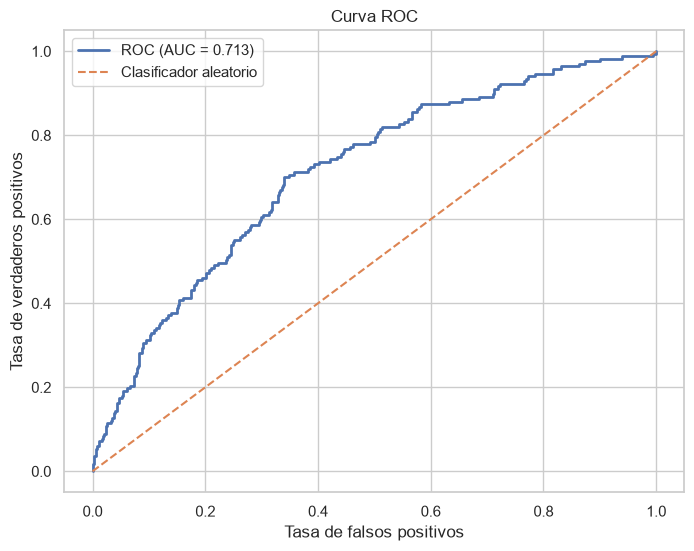

In [19]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"AUC = {auc:.4f}")

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    linewidth=1.5,
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
interpretacion_auc = pd.DataFrame({

    "AUC": [auc],

    "Interpretación": [
        (
            "Excelente" if auc >= 0.90 else
            "Muy buena" if auc >= 0.80 else
            "Aceptable" if auc >= 0.70 else
            "Limitada" if auc >= 0.60 else
            "Deficiente"
        )
    ]

})

interpretacion_auc.round(4)

,AUC,Interpretación
0,0.7131,Aceptable


### Interpretación

La curva ROC obtuvo un **Área Bajo la Curva (AUC) de 0,713**, valor que corresponde a una capacidad discriminante **aceptable**.

Este resultado indica que el modelo logra diferenciar razonablemente entre pacientes que desarrollarán enfermedad coronaria y aquellos que no la desarrollarán, superando claramente el desempeño esperado de un clasificador aleatorio (AUC = 0,5).

No obstante, al utilizar el umbral de decisión por defecto (0,5), el modelo presentó un bajo Recall para la clase positiva, lo que evidencia dificultades para identificar todos los pacientes con enfermedad coronaria.

En consecuencia, aunque la capacidad de discriminación general del modelo es adecuada, futuras mejoras podrían considerar el ajuste del umbral de clasificación o técnicas específicas para tratar el desbalance de clases, con el objetivo de incrementar la detección de pacientes de alto riesgo.

# 6. Interpretación mediante Odds Ratio

Los coeficientes de la regresión logística se expresan originalmente en escala logarítmica (log-odds), lo que dificulta su interpretación directa.

Para facilitar el análisis, se calcularon los **Odds Ratios (OR)** mediante la exponencial de cada coeficiente.

Un **OR > 1** indica que el aumento de la variable incrementa las probabilidades (odds) de desarrollar enfermedad coronaria, mientras que un **OR < 1** indica una disminución de dichas probabilidades.

In [21]:
odds_ratio = pd.DataFrame({

    "Variable": features,

    "Coeficiente": modelo.coef_[0],

    "Odds Ratio": np.exp(modelo.coef_[0])

})

odds_ratio = odds_ratio.sort_values(
    by="Odds Ratio",
    ascending=False
)

odds_ratio.round(3)

,Variable,Coeficiente,Odds Ratio
0,age,0.469,1.598
4,pulsePressure,0.294,1.341
3,glucose,0.152,1.165
1,totChol,0.110,1.117
2,BMI,0.102,1.108


### Interpretación

Los Odds Ratios (OR) permiten interpretar el efecto de cada variable sobre la probabilidad de desarrollar enfermedad coronaria a diez años.

Como las variables fueron previamente estandarizadas mediante `StandardScaler`, cada Odds Ratio representa el cambio en las probabilidades (odds) asociado a un incremento de **una desviación estándar** en la variable correspondiente.

La **edad** presentó el mayor Odds Ratio (OR = 1,598), indicando que un incremento de una desviación estándar en la edad aumenta aproximadamente en un **59,8%** las odds de desarrollar enfermedad coronaria.

La **presión de pulso** mostró el segundo mayor efecto (OR = 1,341), respaldando la decisión metodológica de utilizar esta variable en lugar de incorporar simultáneamente la presión sistólica y diastólica.

La **glucosa** (OR = 1,165), el **colesterol total** (OR = 1,117) y el **IMC** (OR = 1,108) también incrementan las probabilidades estimadas de enfermedad coronaria, aunque con una magnitud menor.

En conjunto, estos resultados son coherentes con los análisis realizados en las Sumativas 1 y 2, donde estas variables demostraron estabilidad estadística y relevancia clínica como factores asociados al riesgo cardiovascular.

In [22]:
resumen_modelo = pd.DataFrame({

    "Indicador": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

resumen_modelo.round(4)

,Indicador,Valor
0,Accuracy,0.8506
1,Precision,0.5882
2,Recall,0.0599
3,F1-score,0.1087
4,AUC,0.7131


# 7. Conclusiones

En esta actividad se desarrolló un modelo de regresión logística para predecir el riesgo de enfermedad coronaria a diez años utilizando el conjunto de datos del Framingham Heart Study.

La selección de variables se fundamentó en los resultados obtenidos durante la Sumativa 1 y la Sumativa 2, considerando la estabilidad estadística de los parámetros, el análisis de robustez, los tamaños del efecto y el diagnóstico de multicolinealidad.

El modelo obtuvo una capacidad discriminante **aceptable (AUC = 0,713)**, evidenciando que es capaz de diferenciar razonablemente entre pacientes con y sin enfermedad coronaria. No obstante, el bajo Recall obtenido indica que el umbral de clasificación por defecto limita la detección de pacientes pertenecientes a la clase minoritaria.

El análisis mediante el Factor de Inflación de la Varianza confirmó la ausencia de problemas importantes de multicolinealidad, validando la incorporación de la variable **pulsePressure** como sustituto de las variables de presión sistólica y diastólica.

En conjunto, los resultados obtenidos proporcionan una base sólida para continuar el desarrollo de modelos predictivos más avanzados durante la siguiente etapa del proyecto, incorporando técnicas de balanceo de clases, optimización de hiperparámetros y comparación con algoritmos de aprendizaje automático de mayor complejidad.